In [1]:
import numpy as np
import os, path
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt

In [2]:
data_format = "decimal"
DATASET_FOLDER_PATH = os.path.join(os.getcwd(), r"dataset\decimal")



BENIGN_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_benign.csv")
DOS_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_DoS.csv")
SPOOFING_GAS_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-GAS.csv")
SPOOFING_RPM_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-RPM.csv")
SPOOFING_SPEED_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-SPEED.csv")
SPOOFING_STEERING_WHEEL_DATASET_PATH = os.path.join(DATASET_FOLDER_PATH, f"{data_format}_spoofing-STEERING_WHEEL.csv")


assert os.path.isfile(BENIGN_DATASET_PATH) & \
    os.path.isfile(DOS_DATASET_PATH) & \
        os.path.isfile(SPOOFING_GAS_DATASET_PATH) & \
            os.path.isfile(SPOOFING_RPM_DATASET_PATH) & \
                os.path.isfile(SPOOFING_SPEED_DATASET_PATH) & \
                    os.path.isfile(SPOOFING_STEERING_WHEEL_DATASET_PATH)

In [3]:
benign_df = pd.read_csv(BENIGN_DATASET_PATH)
dos_df = pd.read_csv(DOS_DATASET_PATH)
spf_gas_df = pd.read_csv(SPOOFING_GAS_DATASET_PATH)
spf_rpm_df = pd.read_csv(SPOOFING_RPM_DATASET_PATH)
spf_speed_df = pd.read_csv(SPOOFING_SPEED_DATASET_PATH)
spf_str_wheel_df = pd.read_csv(SPOOFING_STEERING_WHEEL_DATASET_PATH)



print(f"Length of all benign is {len(benign_df)}")
print(f"Length of all dos is {len(dos_df)}")
print(f"Length of all spoof gas is {len(spf_gas_df)}")
print(f"Length of all spoof rpm is {len(spf_rpm_df)}")
print(f"Length of all spoof speed is {len(spf_speed_df)}")
print(f"Length of all spoof steering wheel is {len(spf_str_wheel_df)}")

Length of all benign is 1223737
Length of all dos is 74663
Length of all spoof gas is 9991
Length of all spoof rpm is 54900
Length of all spoof speed is 24951
Length of all spoof steering wheel is 19977


In [4]:
big_df = pd.concat((benign_df, dos_df, spf_gas_df, spf_rpm_df, spf_speed_df, spf_str_wheel_df), axis=0)

print(f"Length of the new combined dataset is {len(big_df)}")
big_df.head()

Length of the new combined dataset is 1408219


,ID,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,category,specific_class
0,65,96,0,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
1,1068,132,13,160,0,0,0,0,0,BENIGN,BENIGN,BENIGN
2,535,127,255,127,255,127,255,127,255,BENIGN,BENIGN,BENIGN
3,131,15,224,0,0,0,0,0,0,BENIGN,BENIGN,BENIGN
4,936,1,0,39,16,0,0,0,0,BENIGN,BENIGN,BENIGN


In [5]:
# Train test split

label_col = 'label'
category_col = 'category'
class_col = 'specific_class'
CID_col = 'ID'

seed = 42 # leave this as it is, for reproducibility

y = big_df[class_col]

big_df = big_df.drop(columns=[label_col, category_col, class_col, CID_col]) # drop label columns to prevent data leakage

x = big_df

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=seed)


print(f"Data split into {len(x_train)} for training and {len(x_test)} for testing")

Data split into 985753 for training and 422466 for testing


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("Training shape:", x_train_scaled.shape)
print("Testing shape :", x_test_scaled.shape)

Training shape: (985753, 8)
Testing shape : (422466, 8)


In [7]:
from sklearn.ensemble import RandomForestClassifier
import time

rf_model = RandomForestClassifier(n_estimators=100, criterion='gini')

start_time = time.time()

rf_model.fit(x_train_scaled, y_train)

training_time = time.time() - start_time

print(f"Training completed in {training_time:.2f} seconds")

Training completed in 269.69 seconds


In [8]:
y_pred = rf_model.predict(x_test_scaled)

print("Predictions generated.")

Predictions generated.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.6f}")
print(f"Precision: {precision:.6f}")
print(f"Recall   : {recall:.6f}")
print(f"F1 Score : {f1:.6f}")

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=6))

Accuracy : 0.996409
Precision: 0.996710
Recall   : 0.996409
F1 Score : 0.996286

Classification Report
                precision    recall  f1-score   support

        BENIGN   0.999989  1.000000  0.999995    367122
           DoS   1.000000  1.000000  1.000000     22399
           GAS   1.000000  1.000000  1.000000      2997
           RPM   0.915860  0.999939  0.956055     16470
         SPEED   1.000000  0.797862  0.887568      7485
STEERING_WHEEL   1.000000  0.999499  0.999750      5993

      accuracy                       0.996409    422466
     macro avg   0.985975  0.966217  0.973894    422466
  weighted avg   0.996710  0.996409  0.996286    422466



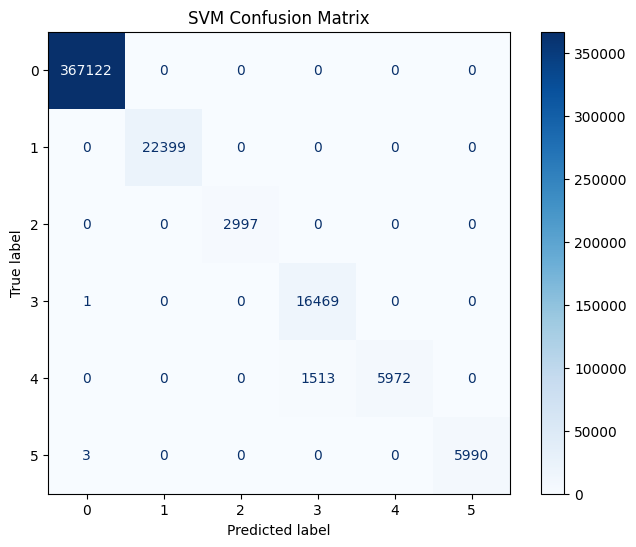

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, cmap='Blues')

plt.title("ٌClassful Random Forest Confusion Matrix")
plt.show()

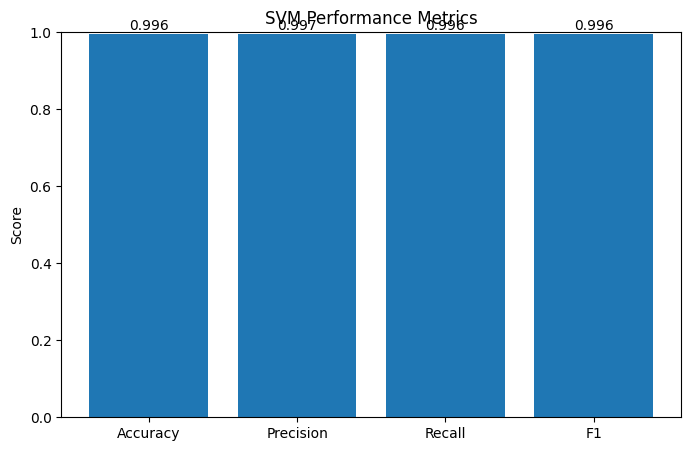

In [ ]:
metrics = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1
}

plt.figure(figsize=(8, 5))
plt.bar(metrics.keys(), metrics.values())
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Binary Random Forest Performance Metrics")

for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.01, f"{value:.3f}", ha='center')

plt.show()

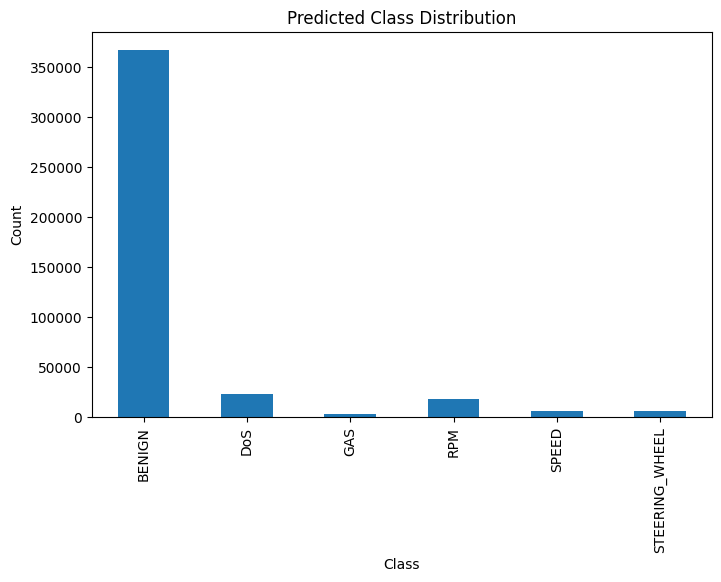

BENIGN            367126
DoS                22399
GAS                 2997
RPM                17982
SPEED               5972
STEERING_WHEEL      5990
Name: count, dtype: int64


In [12]:
import pandas as pd

pred_counts = pd.Series(y_pred).value_counts().sort_index()

plt.figure(figsize=(8, 5))
pred_counts.plot(kind='bar')

plt.title("Predicted Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()
print(pred_counts)

In [ ]:
# from sklearn.metrics import roc_curve, auc

# if len(y.unique()) == 2:

#     y_scores = rf_model.decision_function(x_test_scaled)
#     fpr, tpr, _ = roc_curve(y_test, y_scores, pos_label= 'BENIGN')
#     roc_auc = auc(fpr, tpr)

#     plt.figure(figsize=(8, 6))
#     plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
#     plt.plot([0, 1], [0, 1], '--')

#     plt.xlabel("False Positive Rate")
#     plt.ylabel("True Positive Rate")
#     plt.title("ROC Curve")
#     plt.legend()
#     plt.show()

#     print(f"AUC = {roc_auc:.4f}")